## 1. Import thư viện 

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_predict

from datetime import datetime

import joblib

from sklearn import metrics
print("Thư viện đã import thành công!")

Thư viện đã import thành công!


## 2. Load dữ liệu đã tiền xử lý và feature đã chọn

In [3]:
file_path = r"data/preprocess/preprocess.csv"
df = pd.read_csv(file_path)
print("Kích thước dữ liệu:", df.shape)
print("Các cột dữ liệu:", list(df.columns))
df.head()

Kích thước dữ liệu: (175341, 47)
Các cột dữ liệu: ['dur', 'spkts', 'sbytes', 'sttl', 'sload', 'dload', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'synack', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'proto_arp', 'proto_igmp_icmp_rtp', 'proto_ospf', 'proto_others', 'proto_tcp', 'proto_udp', 'service_-', 'service_dns', 'service_ftp', 'service_ftp-data', 'service_http', 'service_others', 'service_pop3', 'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT', 'state_REQ', 'state_RST', 'state_others', 'label']


,dur,spkts,sbytes,sttl,sload,dload,dloss,sinpkt,dinpkt,sjit,...,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_RST,state_others,label
0,0.121478,6.0,258.0,252.0,14158.9420,8495.3650,0.0,24.29560,8.375000,30.177547,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,0.649902,14.0,734.0,62.0,8395.1120,503571.3000,17.0,49.91500,15.432865,61.426933,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,1.623129,8.0,364.0,62.0,1572.2719,60929.2300,6.0,231.87556,102.737206,9505.476000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,1.681642,12.0,628.0,62.0,2740.1790,3358.6220,3.0,152.87654,90.235725,259.080170,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
4,0.449454,10.0,534.0,254.0,8561.4990,3987.0598,1.0,47.75033,75.659600,2415.837600,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0


## 3. Tách dữ liệu train/test

In [4]:
# Tách dữ liệu
X = df.drop(columns=['label']) 
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (140272, 46) Test: (35069, 46)


In [5]:
print(y.value_counts())
print(y.value_counts(normalize=True).round(4))

label
1    119341
0     56000
Name: count, dtype: int64
label
1    0.6806
0    0.3194
Name: proportion, dtype: float64


## 4. Train model

In [73]:
TARGET_DR = 0.9     # ưu tiên bắt attack
MAX_FPR   = 0.05     # khống chế normal bị nhầm 
N_SPLITS  = 5
RANDOM_STATE = 1

MLP_ATTACK_WEIGHT = 1.0   

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _safe_tag(s: str) -> str:
    return "".join(c if c.isalnum() or c in "-_." else "_" for c in s)

def make_run_dir(tag="UNSW_NB15"):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = RESULTS_DIR / f"{ts}__{_safe_tag(tag)}"
    (run_dir / "figures").mkdir(parents=True, exist_ok=True)
    (run_dir / "reports").mkdir(parents=True, exist_ok=True)
    return run_dir

RUN_DIR = make_run_dir(f"DR{TARGET_DR}_FPR{MAX_FPR}")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

def save_fig(fig, filename):
    out = RUN_DIR / "figures" / filename
    fig.savefig(out, bbox_inches="tight", dpi=300)
    print("Saved figure:", out)

def save_text(text, filename):
    out = RUN_DIR / "reports" / filename
    out.write_text(text, encoding="utf-8")
    print("Saved report:", out)

def align_features(X_ref, X_any):
    """
    - Drop cột thừa
    - Add cột thiếu (fill 0.0)
    - Reorder theo đúng X_ref.columns
    """
    if not (hasattr(X_ref, "columns") and hasattr(X_any, "columns")):
        return X_any
    return X_any.reindex(columns=X_ref.columns, fill_value=0.0)

X_test = align_features(X_train, X_test)

In [ ]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def oof_score_cv(model, X, y, method="predict_proba"):
    pred = cross_val_predict(model, X, y, cv=cv, method=method, n_jobs=-1)
    if method == "predict_proba":
        return pred[:, 1]   # P(Attack)
    return pred             # decision_function

def oof_score_manual_cv(model_factory, X, y, score_fn, fit_kwargs_fn=None):
    oof = np.zeros(len(y), dtype=float)
    is_pandas = hasattr(X, "iloc")

    for tr_idx, va_idx in cv.split(X, y):
        m = model_factory()
        if is_pandas:
            Xtr, ytr = X.iloc[tr_idx], y.iloc[tr_idx]
            Xva      = X.iloc[va_idx]
        else:
            Xtr, ytr = X[tr_idx], y[tr_idx]
            Xva      = X[va_idx]

        fit_kwargs = fit_kwargs_fn(ytr) if fit_kwargs_fn else {}
        m.fit(Xtr, ytr, **fit_kwargs)
        oof[va_idx] = score_fn(m, Xva)

    return oof

def fpr_dr_recall0_far(y_true, y_pred):
    TN, FP, FN, TP = metrics.confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    fpr = FP/(FP+TN) if (FP+TN) else 0.0
    dr  = TP/(TP+FN) if (TP+FN) else 0.0
    r0  = TN/(TN+FP) if (TN+FP) else 0.0
    far = (FP+FN)/(TN+FP+FN+TP) if (TN+FP+FN+TP) else 0.0
    return fpr, dr, r0, far

def pick_threshold_dr_and_fpr(y_true, score, target_dr=0.9, max_fpr=0.05, n=1500):
    """
    Chọn threshold theo ràng buộc kép:
      (1) DR >= target_dr  (ưu tiên bắt Attack)
      (2) FPR <= max_fpr   (khống chế báo động giả)

    Chiến lược chọn:
    A) Nếu có threshold thỏa CẢ 2: chọn FAR nhỏ nhất, rồi FPR nhỏ, rồi DR lớn.
    B) Nếu KHÔNG có threshold thỏa cả 2:
       - Ưu tiên mọi threshold có FPR <= max_fpr (dù DR chưa đạt): chọn DR lớn nhất, rồi FAR nhỏ nhất.
    C) Nếu thậm chí không có threshold nào đạt FPR <= max_fpr:
       - Chọn threshold cho FPR nhỏ nhất (ít báo động giả nhất), rồi DR lớn nhất, rồi FAR nhỏ nhất.
    """
    y_true = np.asarray(y_true).astype(int)
    score  = np.asarray(score).astype(float)

    ths = np.linspace(score.min(), score.max(), n)

    best_both = None   
    best_fpr  = None   
    best_minf = None  

    for thr in ths:
        y_pred = (score >= thr).astype(int)
        fpr, dr, r0, far = fpr_dr_recall0_far(y_true, y_pred)

        # A) thỏa cả 2 ràng buộc
        if (dr >= target_dr) and (fpr <= max_fpr):
            cand = (far, fpr, -dr, thr, -r0)
            if best_both is None or cand < best_both:
                best_both = cand

        # B) chỉ thỏa FPR (giữ báo động giả trước)
        if (fpr <= max_fpr):
            cand = (-dr, far, fpr, thr, -r0)
            if best_fpr is None or cand < best_fpr:
                best_fpr = cand

        # C) fallback cuối: FPR nhỏ nhất
        cand = (fpr, -dr, far, thr, -r0)
        if best_minf is None or cand < best_minf:
            best_minf = cand

    if best_both is not None:
        far, fpr, neg_dr, thr, neg_r0 = best_both
        return float(thr), float(fpr), float(-neg_dr), float(-neg_r0), float(far), True

    # không đạt DR nhưng vẫn giữ FPR <= max_fpr
    if best_fpr is not None:
        neg_dr, far, fpr, thr, neg_r0 = best_fpr
        return float(thr), float(fpr), float(-neg_dr), float(-neg_r0), float(far), False

    # không có threshold nào giữ nổi FPR
    fpr, neg_dr, far, thr, neg_r0 = best_minf
    return float(thr), float(fpr), float(-neg_dr), float(-neg_r0), float(far), False

def plot_confusion_matrix(y_true, y_pred, title, fname, normalize=False):
    """
    Vẽ confusion matrix dạng heatmap
    - normalize=False: hiển thị số lượng (int)
    - normalize=True : hiển thị tỉ lệ theo hàng (float)
    """
    cm = metrics.confusion_matrix(y_true, y_pred, labels=[0,1])

    if normalize:
        cm_show = cm.astype(float)
        row_sum = cm_show.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        cm_show = cm_show / row_sum
        fmt = ".2f"
    else:
        cm_show = cm.astype(int)   
        fmt = "d"

    fig = plt.figure(figsize=(6.2, 5.2))
    ax = sns.heatmap(
        cm_show,
        annot=True,
        fmt=fmt,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Normal(0)", "Attack(1)"],
        yticklabels=["Normal(0)", "Attack(1)"]
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title + (" (Normalized)" if normalize else ""))
    plt.tight_layout()

    save_fig(fig, fname)
    plt.show()

def plot_roc(y_true, score, title, fname):
    fpr, tpr, _ = metrics.roc_curve(y_true, score)
    auc = metrics.roc_auc_score(y_true, score)

    fig = plt.figure(figsize=(6.2, 5.2))
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
    plt.plot([0,1],[0,1], linestyle="--", linewidth=1)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()

    save_fig(fig, fname)
    plt.show()

def build_row_and_report(name, y_true, y_pred, score, thr, ok):
    cm = metrics.confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()
    fpr, dr, r0, far = fpr_dr_recall0_far(y_true, y_pred)

    row = {
        "model": name,
        "thr": float(thr),
        "ok_constraints": bool(ok),
        "TN": int(TN), "FP": int(FP), "FN": int(FN), "TP": int(TP),
        "Accuracy": float(metrics.accuracy_score(y_true, y_pred)),
        "Prec_Attack": float(metrics.precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Prec_Normal": float(metrics.precision_score(y_true, y_pred, pos_label=0, zero_division=0)),
        "DR(Recall_Attack)": float(dr),
        "FPR": float(fpr),
        "Recall0(Specificity)": float(r0),
        "FAR": float(far),
        "F1": float(metrics.f1_score(y_true, y_pred, zero_division=0)),
        "AUC": float(metrics.roc_auc_score(y_true, score)),
    }

    rep = metrics.classification_report(y_true, y_pred, digits=4, zero_division=0)
    return row, cm, rep

def print_full_summary(row, split="TEST"):
    name = row.get("model", "MODEL")
    thr  = row.get("thr", float("nan"))
    ok   = row.get("ok_constraints", None)

    dr   = row.get("DR(Recall_Attack)", row.get("DR", float("nan")))
    spec = row.get("Recall0(Specificity)", row.get("Recall0", float("nan")))

    acc  = row.get("Accuracy", float("nan"))
    prec_a = row.get("Prec_Attack", float("nan"))
    prec_n = row.get("Prec_Normal", float("nan"))
    f1   = row.get("F1", float("nan"))
    auc  = row.get("AUC", float("nan"))
    fpr  = row.get("FPR", float("nan"))
    far  = row.get("FAR", float("nan"))

    TN = row.get("TN", 0); FP = row.get("FP", 0)
    FN = row.get("FN", 0); TP = row.get("TP", 0)

    print("\n" + "═"*72)
    print(f" {name:<6} | {split:<9} | thr={thr:.6f} | ok_constraints={ok}")
    print("─"*72)
    print(f" Acc={acc:.4f} | Prec(A)={prec_a:.4f} | Prec(N)={prec_n:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    print(f" Recall(Attack)={dr*100:.2f}% | FPR={fpr*100:.2f}% | Recall(Normal)={spec*100:.2f}% | FAR={far*100:.2f}%")
    print(f" CM: TN={TN}  FP={FP}  FN={FN}  TP={TP}")
    print("═"*72)

### 1.KNeighborsClassifier

In [ ]:
knn = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=21,
        weights="distance",
        p=2,
        n_jobs=-1
    ))
])

knn_oof = oof_score_cv(knn, X_train, y_train, method="predict_proba")

thr_knn, fpr_knn, dr_knn, r0_knn, far_knn, ok_knn = pick_threshold_dr_and_fpr(
    y_train, knn_oof,
    target_dr=TARGET_DR,
    max_fpr=MAX_FPR
)

knn.fit(X_train, y_train)
knn_test_score = knn.predict_proba(X_test)[:, 1]
knn_test_pred  = (knn_test_score >= thr_knn).astype(int)


════════════════════════════════════════════════════════════════════════
 KNN    | TEST      | thr=0.720480 | ok_constraints=True
────────────────────────────────────────────────────────────────────────
 Acc=0.9328 | Prec(A)=0.9753 | Prec(N)=0.8555 | F1=0.9494 | AUC=0.9871
 Recall(Attack)=92.47% | FPR=4.98% | Recall(Normal)=95.02% | FAR=6.72%
 CM: TN=10642  FP=558  FN=1797  TP=22072
════════════════════════════════════════════════════════════════════════
Saved report: results\20260107_202651__DR0.9_FPR0.05\reports\knn_report.txt
Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\knn_cm.png


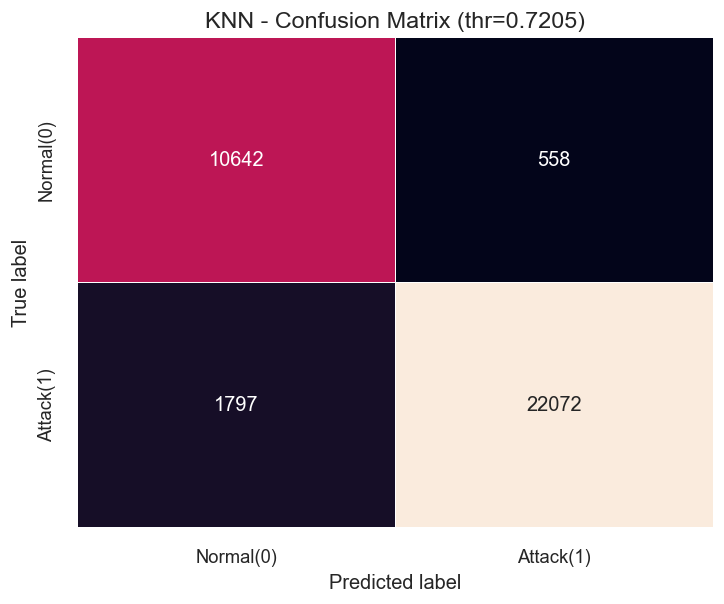

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\knn_cm_norm.png


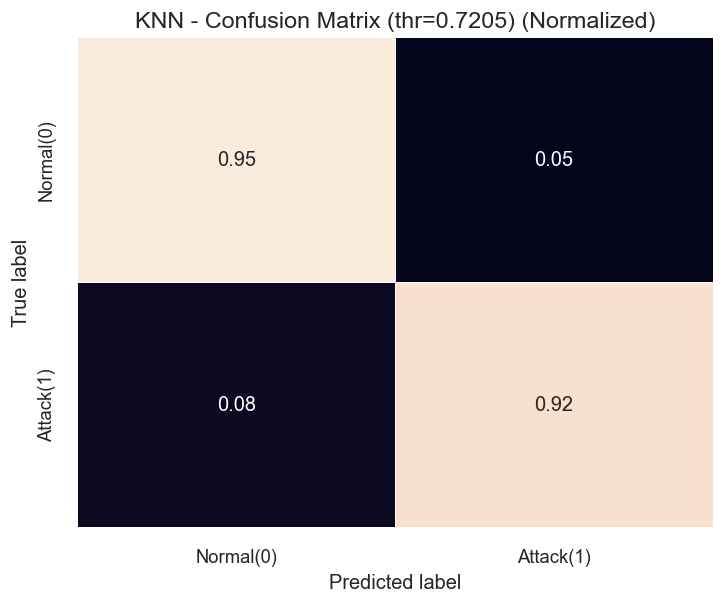

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\knn_roc.png


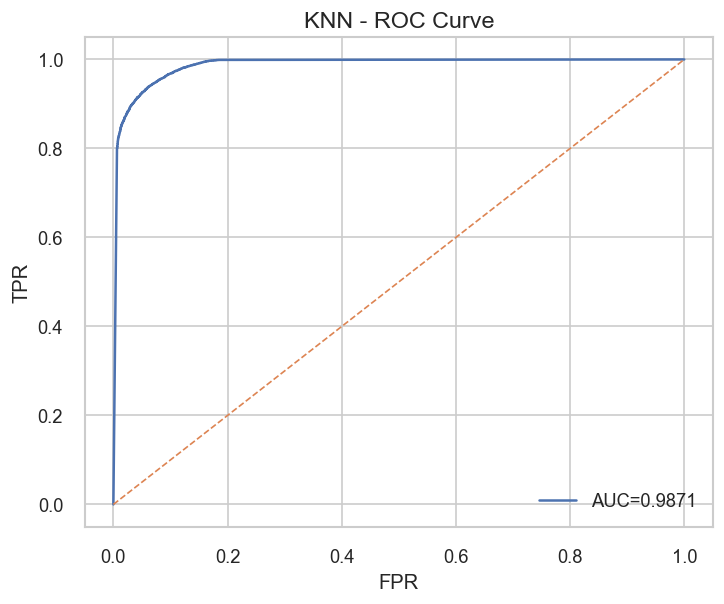

In [75]:
row_knn, cm_knn, rep_knn = build_row_and_report(
    name="KNN",
    y_true=y_test,
    y_pred=knn_test_pred,
    score=knn_test_score,
    thr=thr_knn,
    ok=ok_knn
)
print_full_summary(row_knn, split="TEST")
save_text(
    "=== KNN REPORT ===\n"
    f"Constraints: DR>={TARGET_DR}, FPR<={MAX_FPR}\n"
    f"Chosen threshold: {thr_knn:.6f} | ok_constraints={ok_knn}\n\n"
    "Classification report:\n"
    f"{rep_knn}\n\n"
    "Confusion matrix [[TN FP],[FN TP]]:\n"
    f"{cm_knn}\n",
    filename="knn_report.txt"
)

plot_confusion_matrix(y_test, knn_test_pred, title=f"KNN - Confusion Matrix (thr={thr_knn:.4f})", fname="knn_cm.png", normalize=False)
plot_confusion_matrix(y_test, knn_test_pred, title=f"KNN - Confusion Matrix (thr={thr_knn:.4f})", fname="knn_cm_norm.png", normalize=True)
plot_roc(y_test, knn_test_score, title="KNN - ROC Curve", fname="knn_roc.png")

### 2. MLPClassifier

In [26]:
def make_mlp():
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=300,
            early_stopping=True,      # ổn định hơn
            n_iter_no_change=10,
            random_state=RANDOM_STATE
        ))
    ])

def mlp_score_fn(model, X_val):
    return model.predict_proba(X_val)[:, 1]

def mlp_fit_kwargs_fn(y_train_fold):
    y_train_fold = np.asarray(y_train_fold).astype(int)
    sw = np.where(y_train_fold == 1, float(MLP_ATTACK_WEIGHT), 1.0)
    # pipeline => truyền vào step "mlp" bằng mlp__sample_weight
    return {"mlp__sample_weight": sw}

mlp_oof = oof_score_manual_cv(
    model_factory=make_mlp,
    X=X_train, y=y_train,
    score_fn=mlp_score_fn,
    fit_kwargs_fn=mlp_fit_kwargs_fn
)

thr_mlp, fpr_mlp, dr_mlp, r0_mlp, far_mlp, ok_mlp = pick_threshold_dr_and_fpr(
    y_train, mlp_oof,
    target_dr=TARGET_DR,
    max_fpr=MAX_FPR
)

mlp = make_mlp()
mlp.fit(X_train, y_train, **mlp_fit_kwargs_fn(y_train))

mlp_test_score = mlp.predict_proba(X_test)[:, 1]
mlp_test_pred  = (mlp_test_score >= thr_mlp).astype(int)


════════════════════════════════════════════════════════════════════════
 MLP    | TEST      | thr=0.707805 | ok_constraints=True
────────────────────────────────────────────────────────────────────────
 Acc=0.9370 | Prec(A)=0.9753 | Prec(N)=0.8660 | F1=0.9527 | AUC=0.9904
 Recall(Attack)=93.10% | FPR=5.02% | Recall(Normal)=94.98% | FAR=6.30%
 CM: TN=10638  FP=562  FN=1646  TP=22223
════════════════════════════════════════════════════════════════════════
Saved report: results\20260107_202651__DR0.9_FPR0.05\reports\mlp_report.txt
Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\mlp_cm.png


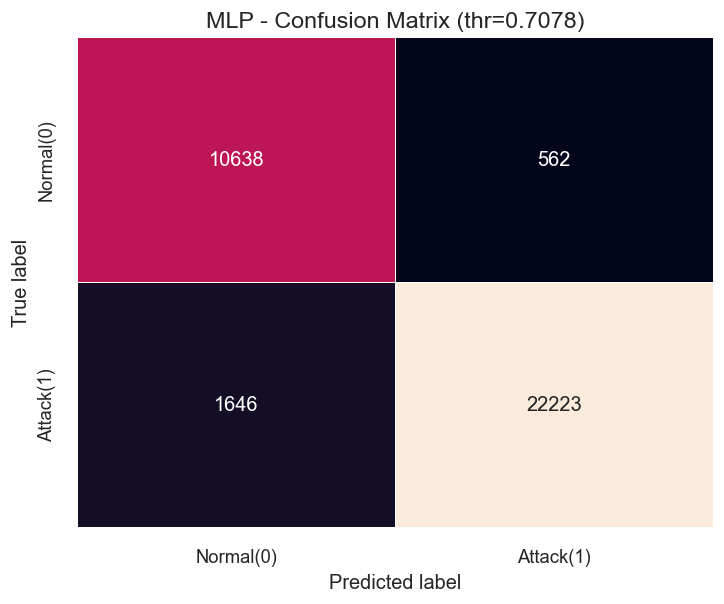

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\mlp_cm_norm.png


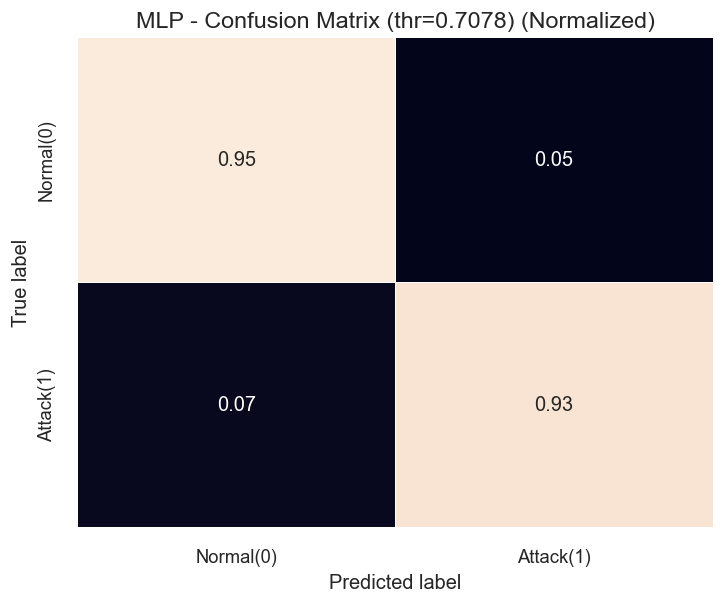

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\mlp_roc.png


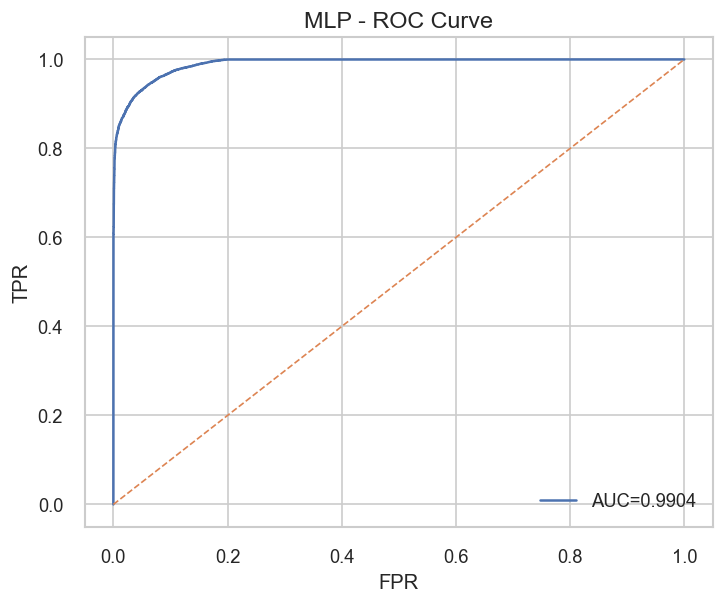

In [76]:
row_mlp, cm_mlp, rep_mlp = build_row_and_report(
    name="MLP",
    y_true=y_test,
    y_pred=mlp_test_pred,
    score=mlp_test_score,
    thr=thr_mlp,
    ok=ok_mlp
)
print_full_summary(row_mlp, split="TEST")
save_text(
    "=== MLP REPORT ===\n"
    f"Constraints: DR>={TARGET_DR}, FPR<={MAX_FPR}\n"
    f"Chosen threshold: {thr_mlp:.6f} | ok_constraints={ok_mlp}\n"
    f"ATTACK_WEIGHT={MLP_ATTACK_WEIGHT}\n\n"
    "Classification report:\n"
    f"{rep_mlp}\n\n"
    "Confusion matrix [[TN FP],[FN TP]]:\n"
    f"{cm_mlp}\n",
    filename="mlp_report.txt"
)

plot_confusion_matrix(
    y_test, mlp_test_pred,
    title=f"MLP - Confusion Matrix (thr={thr_mlp:.4f})",
    fname="mlp_cm.png",
    normalize=False
)
plot_confusion_matrix(
    y_test, mlp_test_pred,
    title=f"MLP - Confusion Matrix (thr={thr_mlp:.4f})",
    fname="mlp_cm_norm.png",
    normalize=True
)
plot_roc(
    y_test, mlp_test_score,
    title="MLP - ROC Curve",
    fname="mlp_roc.png"
)

### 3.SVC

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

svc_base = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=3.0,
        gamma="scale",
        class_weight=None,
        probability=False,
        random_state=RANDOM_STATE
    ))
])

svc = CalibratedClassifierCV(estimator=svc_base, method="sigmoid", cv=3)

svc_oof = oof_score_cv(svc, X_train, y_train, method="predict_proba")

thr_svc, fpr_svc, dr_svc, r0_svc, far_svc, ok_svc = pick_threshold_dr_and_fpr(
    y_train, svc_oof,
    target_dr=TARGET_DR,
    max_fpr=MAX_FPR
)

svc.fit(X_train, y_train)

svc_test_score = svc.predict_proba(X_test)[:, 1]
svc_test_pred  = (svc_test_score >= thr_svc).astype(int)


════════════════════════════════════════════════════════════════════════
 SVC    | TEST      | thr=0.858472 | ok_constraints=True
────────────────────────────────────────────────────────────────────────
 Acc=0.9265 | Prec(A)=0.9753 | Prec(N)=0.8401 | F1=0.9443 | AUC=0.9860
 Recall(Attack)=91.51% | FPR=4.94% | Recall(Normal)=95.06% | FAR=7.35%
 CM: TN=10647  FP=553  FN=2026  TP=21843
════════════════════════════════════════════════════════════════════════
Saved report: results\20260107_202651__DR0.9_FPR0.05\reports\svc_report.txt
Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\svc_cm.png


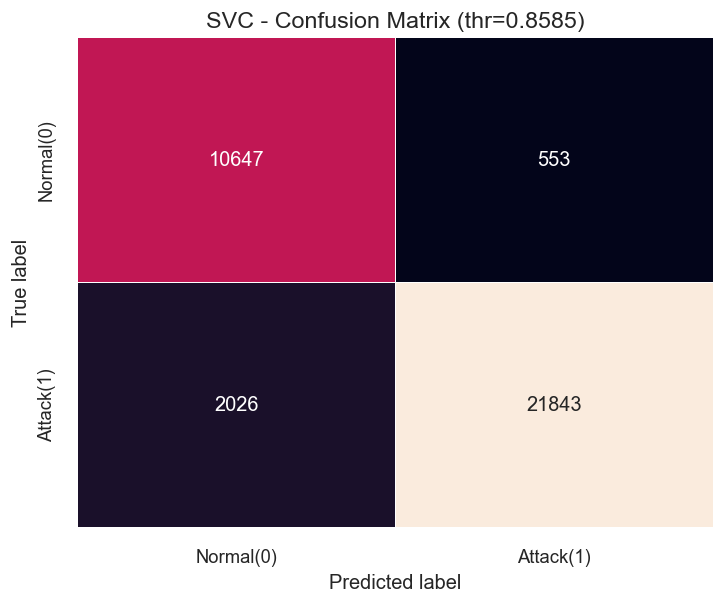

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\svc_cm_norm.png


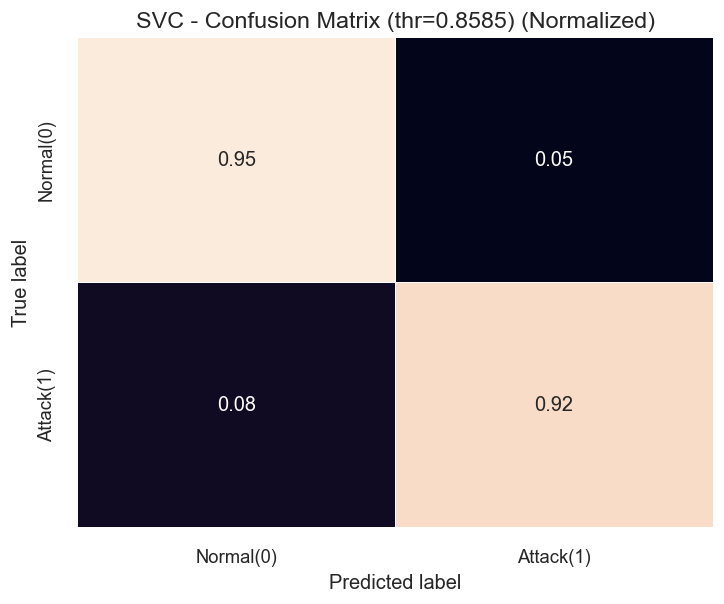

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\svc_roc.png


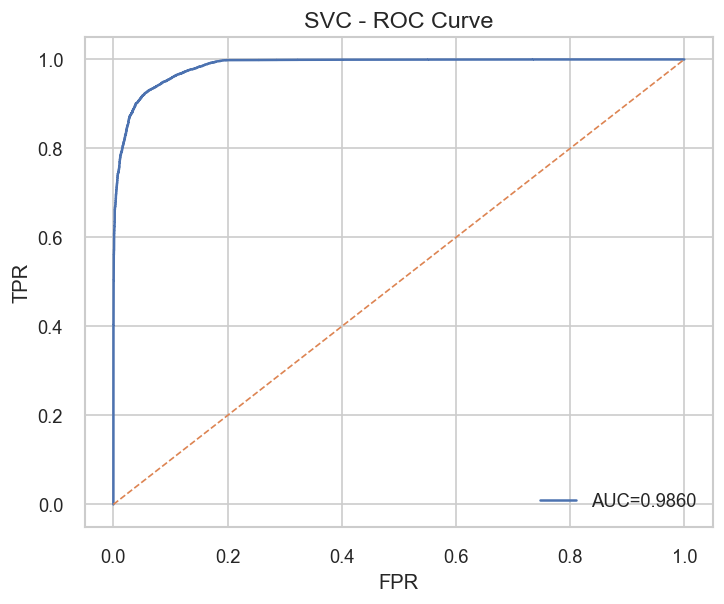

In [77]:
row_svc, cm_svc, rep_svc = build_row_and_report(
    name="SVC",
    y_true=y_test,
    y_pred=svc_test_pred,
    score=svc_test_score,
    thr=thr_svc,
    ok=ok_svc
)
print_full_summary(row_svc, split="TEST")
save_text(
    "=== SVC REPORT ===\n"
    f"Constraints: DR>={TARGET_DR}, FPR<={MAX_FPR}\n"
    f"Chosen threshold: {thr_svc:.6f} | ok_constraints={ok_svc}\n\n"
    "Classification report:\n"
    f"{rep_svc}\n\n"
    "Confusion matrix [[TN FP],[FN TP]]:\n"
    f"{cm_svc}\n",
    filename="svc_report.txt"
)

plot_confusion_matrix(
    y_test, svc_test_pred,
    title=f"SVC - Confusion Matrix (thr={thr_svc:.4f})",
    fname="svc_cm.png",
    normalize=False
)
plot_confusion_matrix(
    y_test, svc_test_pred,
    title=f"SVC - Confusion Matrix (thr={thr_svc:.4f})",
    fname="svc_cm_norm.png",
    normalize=True
)
plot_roc(
    y_test, svc_test_score,
    title="SVC - ROC Curve",
    fname="svc_roc.png"
)

### 4. Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight=None  
)

rf_oof = oof_score_cv(rf, X_train, y_train, method="predict_proba")

thr_rf, fpr_rf, dr_rf, r0_rf, far_rf, ok_rf = pick_threshold_dr_and_fpr(
    y_train, rf_oof,
    target_dr=TARGET_DR,
    max_fpr=MAX_FPR
)

rf.fit(X_train, y_train)
rf_test_score = rf.predict_proba(X_test)[:, 1]
rf_test_pred  = (rf_test_score >= thr_rf).astype(int)


════════════════════════════════════════════════════════════════════════
 RF     | TEST      | thr=0.641094 | ok_constraints=True
────────────────────────────────────────────────────────────────────────
 Acc=0.9561 | Prec(A)=0.9772 | Prec(N)=0.9138 | F1=0.9674 | AUC=0.9935
 Recall(Attack)=95.79% | FPR=4.77% | Recall(Normal)=95.23% | FAR=4.39%
 CM: TN=10666  FP=534  FN=1006  TP=22863
════════════════════════════════════════════════════════════════════════
Saved report: results\20260107_202651__DR0.9_FPR0.05\reports\rf_report.txt
Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\rf_cm.png


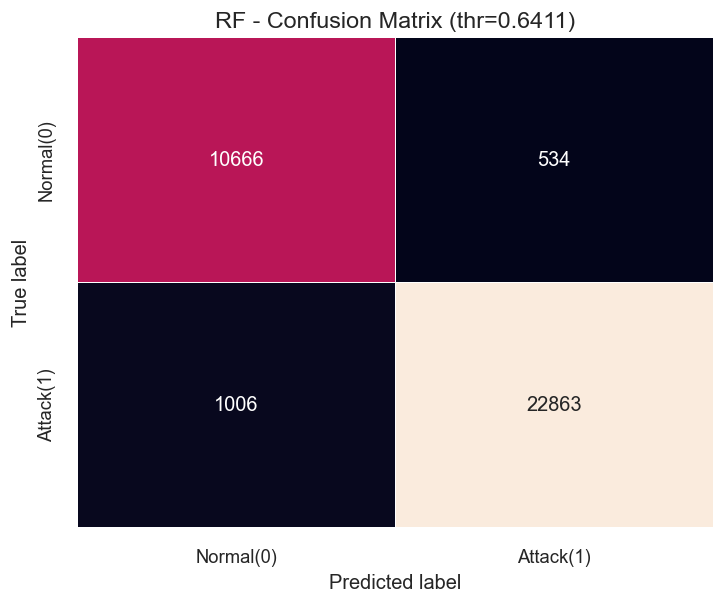

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\rf_cm_norm.png


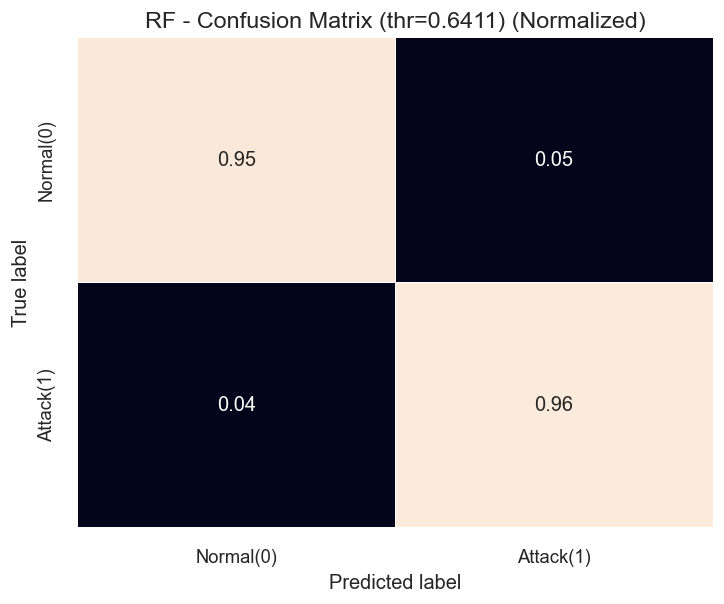

Saved figure: results\20260107_202651__DR0.9_FPR0.05\figures\rf_roc.png


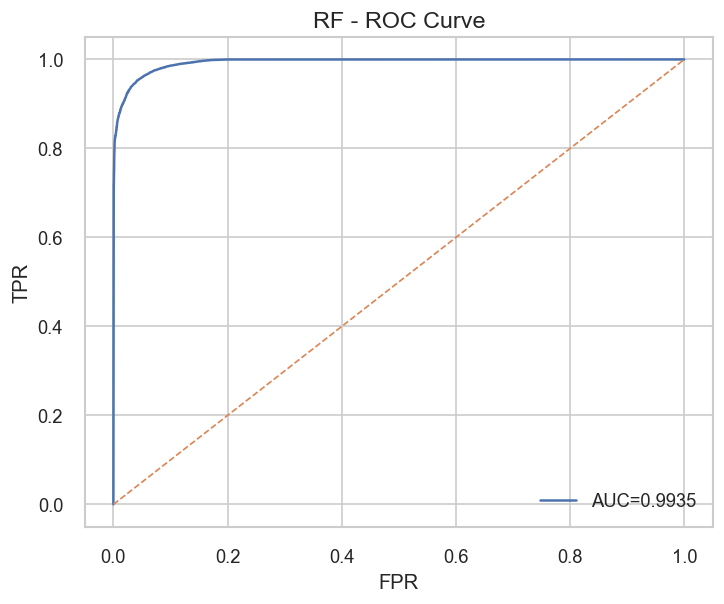

In [ ]:
row_rf, cm_rf, rep_rf = build_row_and_report(
    name="RF",
    y_true=y_test,
    y_pred=rf_test_pred,
    score=rf_test_score,
    thr=thr_rf,
    ok=ok_rf
)
print_full_summary(row_rf, split="TEST")

save_text(
    "=== RANDOM FOREST REPORT ===\n"
    f"Constraints: DR>={TARGET_DR}, FPR<={MAX_FPR}\n"
    f"Chosen threshold: {thr_rf:.6f} | ok_constraints={ok_rf}\n\n"
    "Classification report:\n"
    f"{rep_rf}\n\n"
    "Confusion matrix [[TN FP],[FN TP]]:\n"
    f"{cm_rf}\n",
    filename="rf_report.txt"
)

plot_confusion_matrix(
    y_test, rf_test_pred,
    title=f"RF - Confusion Matrix (thr={thr_rf:.4f})",
    fname="rf_cm.png",
    normalize=False
)
plot_confusion_matrix(
    y_test, rf_test_pred,
    title=f"RF - Confusion Matrix (thr={thr_rf:.4f})",
    fname="rf_cm_norm.png",
    normalize=True
)
plot_roc(
    y_test, rf_test_score,
    title="RF - ROC Curve",
    fname="rf_roc.png"
)

### 5.XGboost

In [ ]:
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1,
    gamma=0.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

xgb_oof = oof_score_cv(xgb, X_train, y_train, method="predict_proba")

thr_xgb, fpr_xgb, dr_xgb, r0_xgb, far_xgb, ok_xgb = pick_threshold_dr_and_fpr(
    y_train, xgb_oof,
    target_dr=TARGET_DR,
    max_fpr=MAX_FPR
)

xgb.fit(X_train, y_train)
xgb_test_score = xgb.predict_proba(X_test)[:, 1]
xgb_test_pred  = (xgb_test_score >= thr_xgb).astype(int)


════════════════════════════════════════════════════════════════════════
 XGB    | TEST      | thr=0.649098 | ok_constraints=True
────────────────────────────────────────────────────────────────────────
 Acc=0.9541 | Prec(A)=0.9760 | Prec(N)=0.9102 | F1=0.9659 | AUC=0.9937
 Recall(Attack)=95.60% | FPR=5.01% | Recall(Normal)=94.99% | FAR=4.59%
 CM: TN=10639  FP=561  FN=1050  TP=22819
════════════════════════════════════════════════════════════════════════
Saved report: results\20260107_165943__DR0.9_FPR0.05\reports\xgb_report.txt
Saved figure: results\20260107_165943__DR0.9_FPR0.05\figures\xgb_cm.png


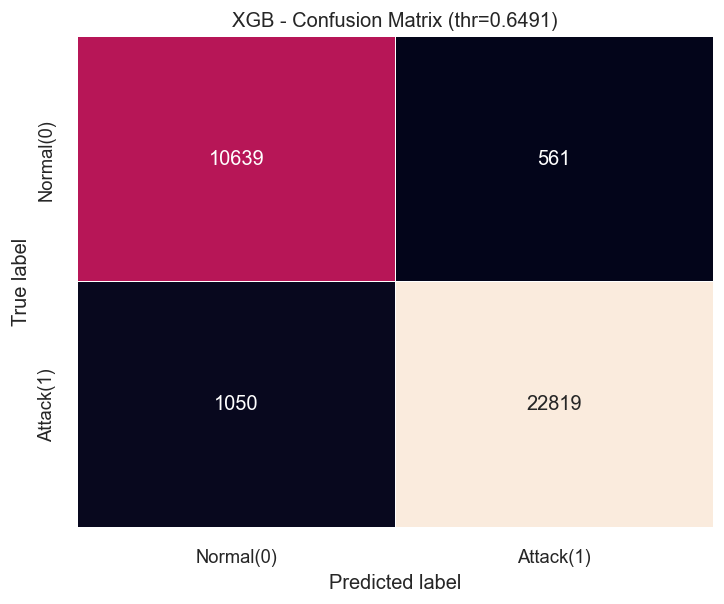

Saved figure: results\20260107_165943__DR0.9_FPR0.05\figures\xgb_cm_norm.png


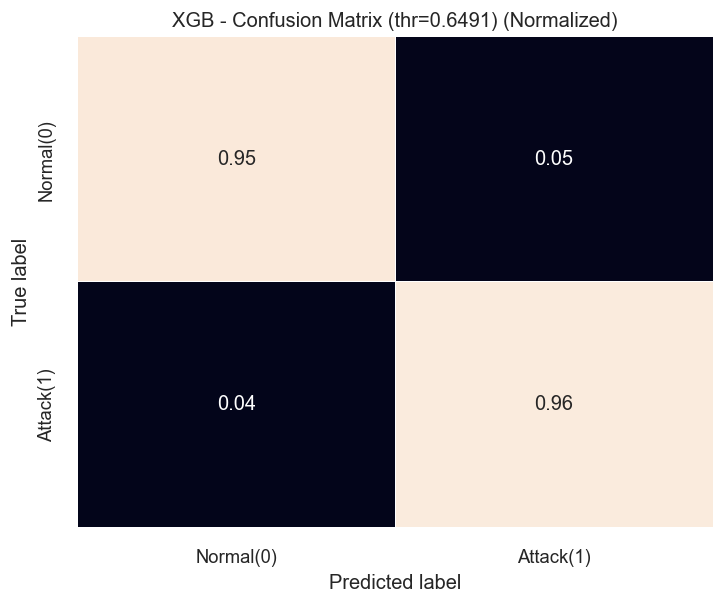

Saved figure: results\20260107_165943__DR0.9_FPR0.05\figures\xgb_roc.png


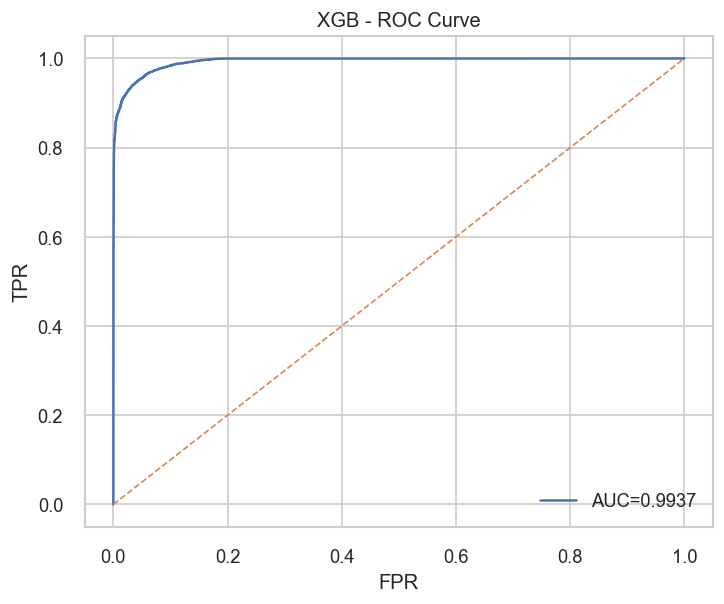

In [ ]:
row_xgb, cm_xgb, rep_xgb = build_row_and_report(
    name="XGB",
    y_true=y_test,
    y_pred=xgb_test_pred,
    score=xgb_test_score,
    thr=thr_xgb,
    ok=ok_xgb
)
print_full_summary(row_xgb, split="TEST")

save_text(
    "=== XGBOOST REPORT ===\n"
    f"Constraints: DR>={TARGET_DR}, FPR<={MAX_FPR}\n"
    f"Chosen threshold: {thr_xgb:.6f} | ok_constraints={ok_xgb}\n\n"
    "Classification report:\n"
    f"{rep_xgb}\n\n"
    "Confusion matrix [[TN FP],[FN TP]]:\n"
    f"{cm_xgb}\n",
    filename="xgb_report.txt"
)

plot_confusion_matrix(
    y_test, xgb_test_pred,
    title=f"XGB - Confusion Matrix (thr={thr_xgb:.4f})",
    fname="xgb_cm.png",
    normalize=False
)
plot_confusion_matrix(
    y_test, xgb_test_pred,
    title=f"XGB - Confusion Matrix (thr={thr_xgb:.4f})",
    fname="xgb_cm_norm.png",
    normalize=True
)
plot_roc(
    y_test, xgb_test_score,
    title="XGB - ROC Curve",
    fname="xgb_roc.png"
)

## 5. Đánh giá các mô hình

In [ ]:
results = {}

results["KNN"] = (row_knn["Accuracy"], row_knn["DR(Recall_Attack)"], row_knn["FPR"], row_knn["AUC"])
results["MLP"] = (row_mlp["Accuracy"], row_mlp["DR(Recall_Attack)"], row_mlp["FPR"], row_mlp["AUC"])
results["SVC"] = (row_svc["Accuracy"], row_svc["DR(Recall_Attack)"], row_svc["FPR"], row_svc["AUC"])
results["RF"]  = (row_rf["Accuracy"],  row_rf["DR(Recall_Attack)"],  row_rf["FPR"], row_rf["AUC"])
results["XGB"] = (row_xgb["Accuracy"], row_xgb["DR(Recall_Attack)"], row_xgb["FPR"], row_xgb["AUC"])

results_df = pd.DataFrame(results, index=["Acc","Recall_Attack", "FPR", "AUC"]).T
print(results_df.sort_values(["FPR", "Recall_Attack"], ascending=[True, False]).round(4))

        Acc  Recall_Attack     FPR     AUC
RF   0.9561         0.9579  0.0477  0.9935
SVC  0.9265         0.9151  0.0494  0.9860
KNN  0.9328         0.9247  0.0498  0.9871
XGB  0.9541         0.9560  0.0501  0.9937
MLP  0.9370         0.9310  0.0502  0.9904


## 6. Trực quan hoá kết quả dự đoán

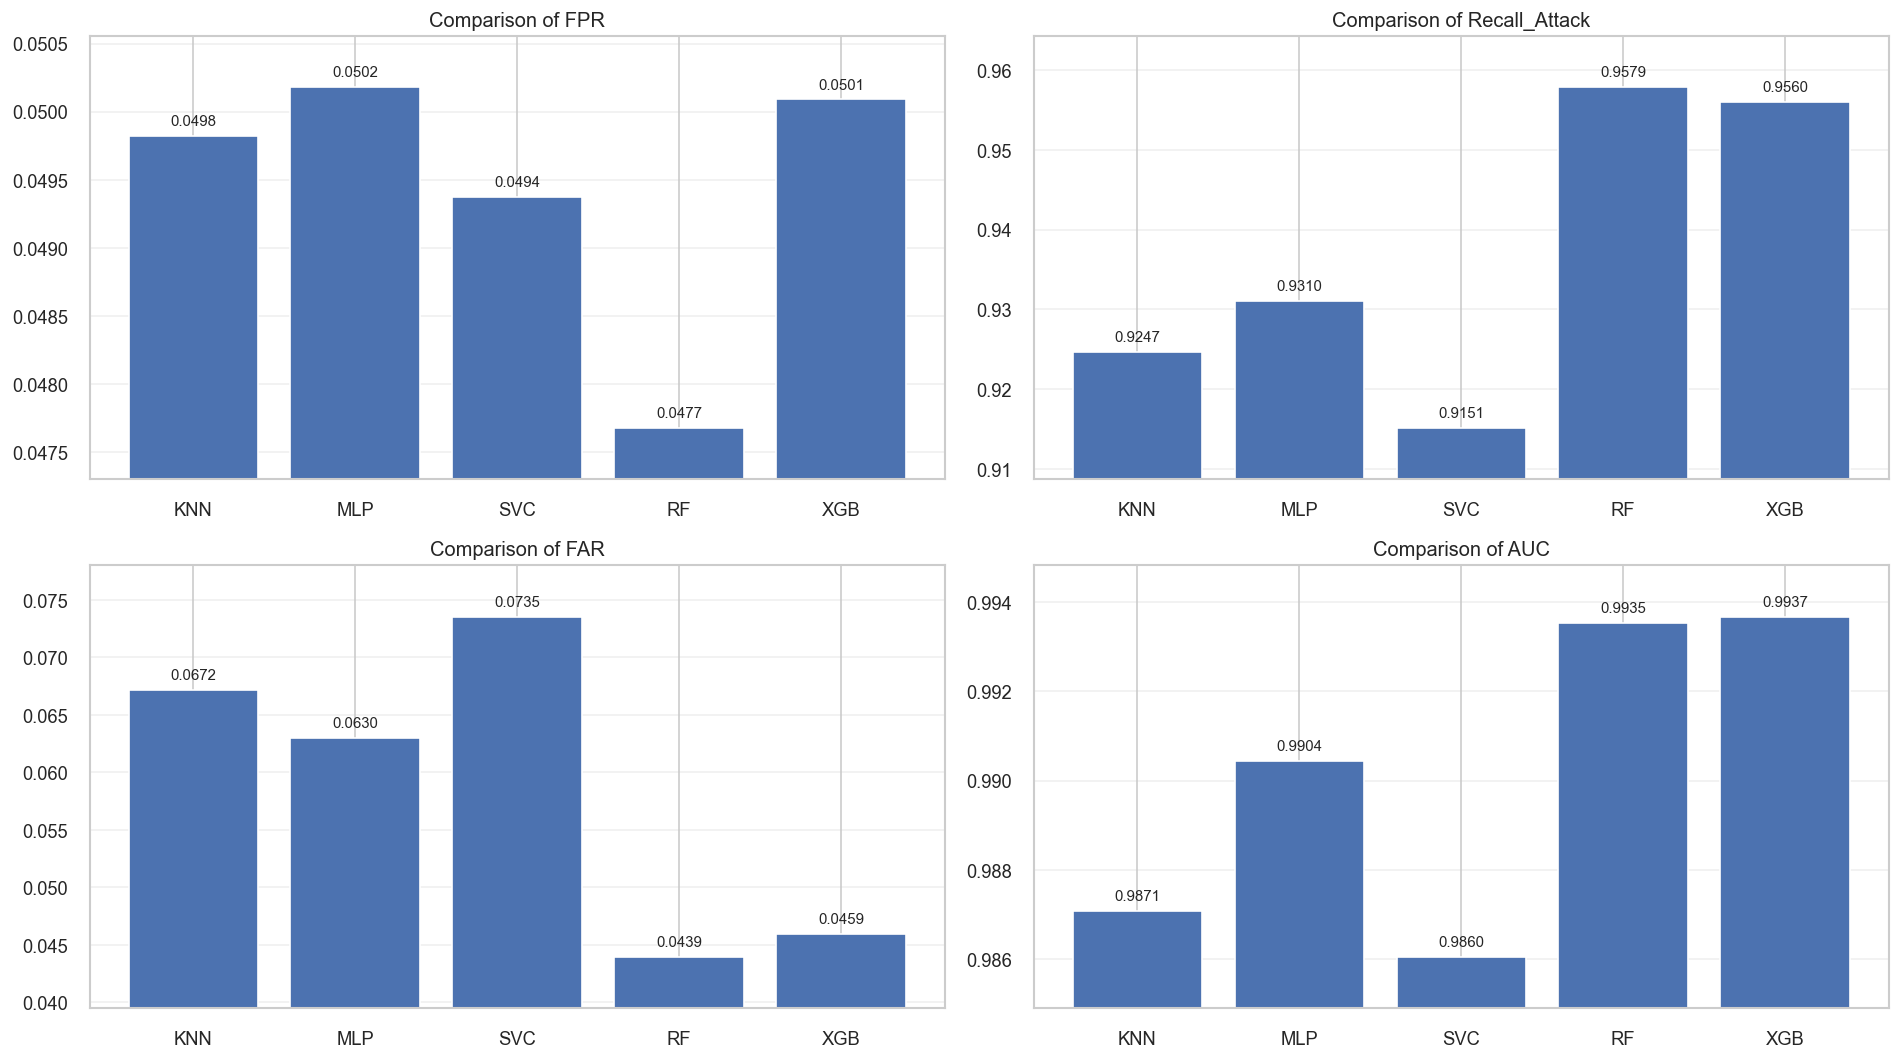

In [51]:
df_plot = results_df.copy()
order = list(df_plot.index)  # hoặc tự set ["KNN","MLP","SVC","RF","XGB"]

metrics_to_plot = [
    ("FPR",           "Comparison of FPR"),
    ("Recall_Attack", "Comparison of Recall_Attack"),
    ("FAR",           "Comparison of FAR"),
    ("AUC",           "Comparison of AUC"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

for i, (col, title) in enumerate(metrics_to_plot):
    ax = axes[i]

    # 4) An toàn nếu thiếu cột
    if col not in df_plot.columns:
        ax.set_title(f"{title} (missing column: {col})")
        ax.axis("off")
        continue

    vals = df_plot[col].astype(float).values
    x = np.arange(len(df_plot.index))

    bars = ax.bar(x, vals)  # giữ màu mặc định
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot.index, rotation=0)
    ax.grid(True, axis="y", alpha=0.3)

    # 5) set ylim cho dễ nhìn + in số trên cột
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    pad = (vmax - vmin) * 0.15 if vmax > vmin else (abs(vmax) * 0.15 + 1e-6)
    ax.set_ylim(max(0, vmin - pad), vmax + pad)

    for b, v in zip(bars, vals):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + pad*0.15,
            f"{v:.4f}",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()
plt.show()


In [60]:
df_out = results_df.copy()

df_out["model"] = df_out.index
df_out = df_out.reset_index(drop=True)

sort_by = []
ascending = []

if "ok_constraints" in df_out.columns:
    sort_by.append("ok_constraints"); ascending.append(False)
if "FPR" in df_out.columns:
    sort_by.append("FPR"); ascending.append(True)
if "FN" in df_out.columns:
    sort_by.append("FN"); ascending.append(True)
if "FAR" in df_out.columns:
    sort_by.append("FAR"); ascending.append(True)
if "Recall_Attack" in df_out.columns:
    sort_by.append("Recall_Attack"); ascending.append(False)
if "AUC" in df_out.columns:
    sort_by.append("AUC"); ascending.append(False)

if sort_by:
    df_out = df_out.sort_values(by=sort_by, ascending=ascending).reset_index(drop=True)

print("=== BẢNG SO SÁNH CHI TIẾT (OOF TRAIN) ===")
show_cols = ["model","ok_constraints","FPR","FN","FAR","Recall_Attack","Recall_Normal","AUC","thr"]
show_cols = [c for c in show_cols if c in df_out.columns]
print(df_out[show_cols].round(4).to_string(index=False))

best = df_out.iloc[0]
print("\n=== KẾT QUẢ ===")
print(f"Mô hình đứng #1 : {best['model']}")

if "FPR" in df_out.columns:           print(f"  - FPR: {best['FPR']:.4f}")
if "FN" in df_out.columns:            print(f"  - FN : {int(best['FN'])}")
if "Recall_Attack" in df_out.columns: print(f"  - Recall_Attack: {best['Recall_Attack']:.4f}")
if "Recall_Normal" in df_out.columns: print(f"  - Recall_Normal: {best['Recall_Normal']:.4f}")
if "FAR" in df_out.columns:           print(f"  - FAR: {best['FAR']:.4f}")
if "AUC" in df_out.columns:           print(f"  - AUC: {best['AUC']:.4f}")
if "thr" in df_out.columns:           print(f"  - thr: {best['thr']:.6f}")
if "ok_constraints" in df_out.columns:print(f"  - ok_constraints: {bool(best['ok_constraints'])}")

print("\n=== PHÂN TÍCH CHI TIẾT ===")

MAX_FPR_FOR_COMMENT = 0.05
MAX_FN_FOR_COMMENT  = 2000
MIN_RECALLA_COMMENT = 0.90

for _, r in df_out.iterrows():
    name = r.get("model", "MODEL")
    fpr  = r.get("FPR", None)
    fn   = r.get("FN", None)
    recA = r.get("Recall_Attack", None)
    recN = r.get("Recall_Normal", None)
    far  = r.get("FAR", None)
    auc  = r.get("AUC", None)
    thr  = r.get("thr", None)
    okc  = r.get("ok_constraints", None)

    comment = []
    if okc is not None:
        comment.append("Đạt ràng buộc" if bool(okc) else "Không đạt ràng buộc")
    if fpr is not None:
        comment.append("Ít báo động sai" if float(fpr) <= MAX_FPR_FOR_COMMENT else "Báo động sai hơi cao")
    if fn is not None:
        comment.append("Ít lọt attack" if int(fn) <= MAX_FN_FOR_COMMENT else "Lọt attack còn nhiều")
    if recA is not None:
        comment.append("Bắt attack tốt" if float(recA) >= MIN_RECALLA_COMMENT else "Bắt attack chưa tốt")

    print(f"{name}:")
    if fpr is not None:  print(f"  - FPR: {float(fpr):.4f}")
    if fn  is not None:  print(f"  - FN : {int(fn)}")
    if recA is not None: print(f"  - Recall_Attack: {float(recA):.4f}")
    if recN is not None: print(f"  - Recall_Normal: {float(recN):.4f}")
    if far is not None:  print(f"  - FAR: {float(far):.4f}")
    if auc is not None:  print(f"  - AUC: {float(auc):.4f}")
    if thr is not None:  print(f"  - thr: {float(thr):.6f}")
    if okc is not None:  print(f"  - ok_constraints: {bool(okc)}")
    print(f"  - Nhận xét: {', '.join(comment)}\n")

=== BẢNG SO SÁNH CHI TIẾT (OOF TRAIN) ===
model    FPR    FAR  Recall_Attack    AUC
   RF 0.0477 0.0439         0.9579 0.9935
  SVC 0.0494 0.0735         0.9151 0.9860
  KNN 0.0498 0.0672         0.9247 0.9871
  XGB 0.0501 0.0459         0.9560 0.9937
  MLP 0.0502 0.0630         0.9310 0.9904

=== KẾT QUẢ ===
Mô hình đứng #1 : RF
  - FPR: 0.0477
  - Recall_Attack: 0.9579
  - FAR: 0.0439
  - AUC: 0.9935

=== PHÂN TÍCH CHI TIẾT ===
RF:
  - FPR: 0.0477
  - Recall_Attack: 0.9579
  - FAR: 0.0439
  - AUC: 0.9935
  - Nhận xét: Ít báo động sai, Bắt attack tốt

SVC:
  - FPR: 0.0494
  - Recall_Attack: 0.9151
  - FAR: 0.0735
  - AUC: 0.9860
  - Nhận xét: Ít báo động sai, Bắt attack tốt

KNN:
  - FPR: 0.0498
  - Recall_Attack: 0.9247
  - FAR: 0.0672
  - AUC: 0.9871
  - Nhận xét: Ít báo động sai, Bắt attack tốt

XGB:
  - FPR: 0.0501
  - Recall_Attack: 0.9560
  - FAR: 0.0459
  - AUC: 0.9937
  - Nhận xét: Báo động sai hơi cao, Bắt attack tốt

MLP:
  - FPR: 0.0502
  - Recall_Attack: 0.9310
  - FAR: 0.

## 7. Dự đoán thử và đánh giá chi tiết

DỰ ĐOÁN THỬ & ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION)
Lấy 10000 mẫu từ TEST (replace=False)
----------------------------------------------------------------------
BẢNG KẾT QUẢ (sample) - dễ đọc theo từng model
              KNN             MLP             SVC              RF             XGB        
   y_true   score pred ok   score pred ok   score pred ok   score pred ok   score pred ok
0       0  0.0000    0  ✓  0.0003    0  ✓  0.0112    0  ✓  0.0000    0  ✓  0.0067    0  ✓
1       0  0.0000    0  ✓  0.0000    0  ✓  0.0053    0  ✓  0.0000    0  ✓  0.0000    0  ✓
2       0  0.0000    0  ✓  0.0000    0  ✓  0.0123    0  ✓  0.0000    0  ✓  0.0001    0  ✓
3       0  0.0000    0  ✓  0.0000    0  ✓  0.0096    0  ✓  0.0000    0  ✓  0.0000    0  ✓
4       0  0.0000    0  ✓  0.0000    0  ✓  0.0055    0  ✓  0.0000    0  ✓  0.0001    0  ✓
5       1  1.0000    1  ✓  0.9998    1  ✓  0.9063    1  ✓  0.9950    1  ✓  0.9997    1  ✓
6       1  0.8672    1  ✓  0.9793    1  ✓  0.9028    1  ✓  0.9550    1  ✓  

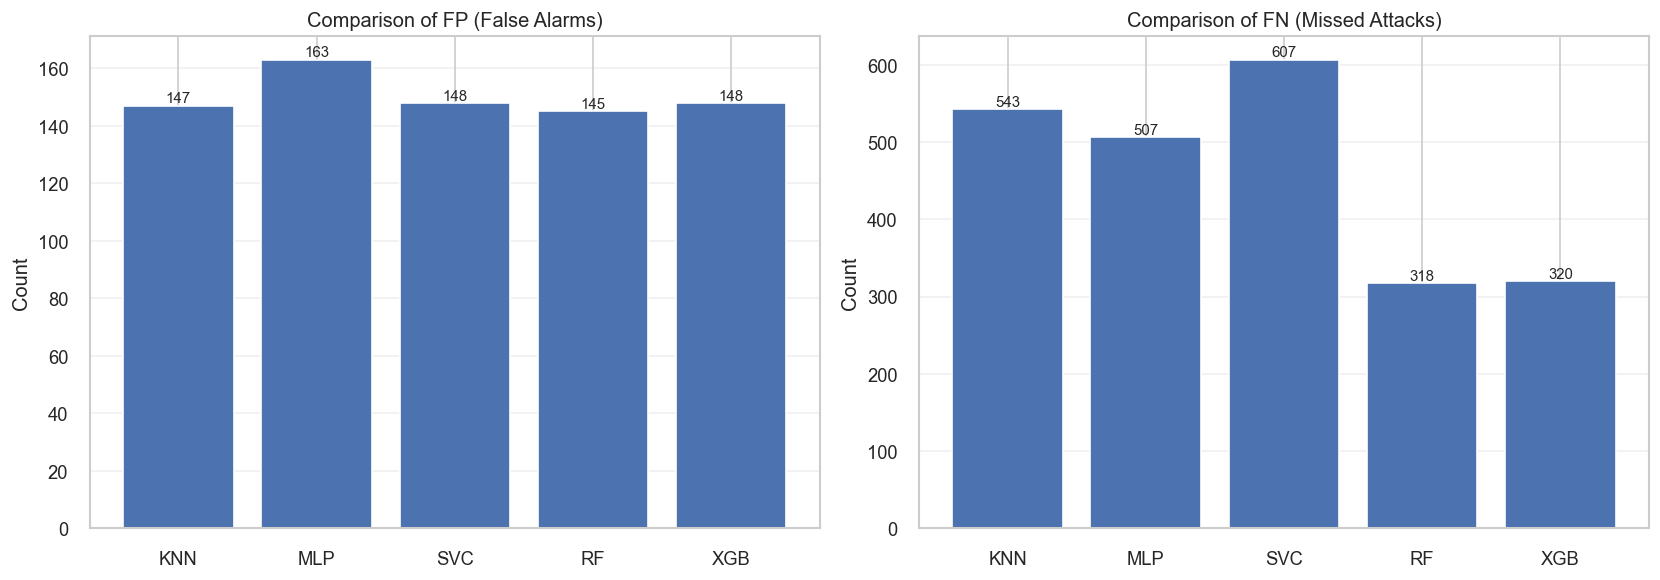

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import metrics

print("DỰ ĐOÁN THỬ & ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION)")
print("="*70)

SEED = 1
SAMPLE_N = 10000          # số mẫu test để “dự đoán thử”
PRINT_N = 20             # in chi tiết N dòng đầu
REPLACE = False          # nên False để không bị trùng mẫu (giống “test thử” hơn)

rng = np.random.default_rng(SEED)

if hasattr(y_test, "reset_index"):
    y_test2 = y_test.reset_index(drop=True)
else:
    y_test2 = np.asarray(y_test)

n_test = len(y_test2)
sample_n = min(SAMPLE_N, n_test)

sample_idx = rng.choice(n_test, size=sample_n, replace=REPLACE)

def take_rows(X, idx):
    # X là pandas DataFrame -> dùng iloc
    if hasattr(X, "iloc"):
        return X.iloc[idx].reset_index(drop=True)
    # X là numpy array -> slicing bình thường
    return X[idx]

X_s = take_rows(X_test, sample_idx)
y_s = y_test2.iloc[sample_idx].reset_index(drop=True) if hasattr(y_test2, "iloc") else y_test2[sample_idx]

print(f"Lấy {len(sample_idx)} mẫu từ TEST (replace={REPLACE})")
print("-"*70)

model_pack = [
    ("KNN", knn, thr_knn, "proba"),
    ("MLP", mlp, thr_mlp, "proba"),
    ("SVC", svc, thr_svc, "proba"),      
    ("RF",  rf,  thr_rf,  "proba"),
    ("XGB", xgb, thr_xgb, "proba"),
]

def get_score(model, X, score_type="proba"):
    if score_type == "proba":
        p = model.predict_proba(X)
        return p[:, 1]  # P(Attack=1)
    elif score_type == "decision":
        s = model.decision_function(X)
        # decision_function có thể ra [-inf, +inf], vẫn dùng được để so với thr
        return np.asarray(s).astype(float)
    else:
        # fallback: nếu không có score, dùng predict (0/1) luôn
        return model.predict(X)

results_table = pd.DataFrame({
    "y_true": y_s.astype(int).values
})

for name, model, thr, stype in model_pack:
    score = get_score(model, X_s, stype)
    y_pred = (score >= thr).astype(int)

    results_table[f"{name}_score"] = score
    results_table[f"{name}_pred"]  = y_pred
    results_table[f"{name}_ok"]    = (y_pred == results_table["y_true"]).astype(int)

def pretty_sample_table(results_table, model_pack, n=20, score_decimals=4):
    models = [name for name, _, _, _ in model_pack]

    cols = [("","y_true")]
    for m in models:
        cols += [(m, "score"), (m, "pred"), (m, "ok")]

    pretty = pd.DataFrame(index=results_table.index, columns=pd.MultiIndex.from_tuples(cols))

    pretty[("","y_true")] = results_table["y_true"].astype(int)

    for m in models:
        pretty[(m,"score")] = results_table[f"{m}_score"].astype(float).round(score_decimals)
        pretty[(m,"pred")]  = results_table[f"{m}_pred"].astype(int)

        ok01 = results_table[f"{m}_ok"].astype(int)
        pretty[(m,"ok")] = ok01.map({1:"✓", 0:"✗"})

    head = pretty.head(n)

    print("BẢNG KẾT QUẢ (sample) - dễ đọc theo từng model")
    print(head.to_string(index=True))

    return head

# Gọi hàm
_ = pretty_sample_table(results_table, model_pack, n=PRINT_N, score_decimals=4)
print("-"*70)

def summarize_one(y_true, y_pred, score=None):
    cm = metrics.confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()

    recall_attack = TP/(TP+FN) if (TP+FN) else 0.0
    recall_normal = TN/(TN+FP) if (TN+FP) else 0.0
    fpr = FP/(FP+TN) if (FP+TN) else 0.0
    far = (FP+FN)/(TN+FP+FN+TP) if (TN+FP+FN+TP) else 0.0

    prec_a = TP/(TP+FP) if (TP+FP) else 0.0   # precision attack
    prec_n = TN/(TN+FN) if (TN+FN) else 0.0   # precision normal
    f1_a = metrics.f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    try:
        auc = metrics.roc_auc_score(y_true, score) if score is not None else np.nan
    except Exception:
        auc = np.nan

    return {
        "TN":TN, "FP":FP, "FN":FN, "TP":TP,
        "Recall_Attack": recall_attack,
        "Recall_Normal": recall_normal,
        "FPR": fpr,
        "FAR": far,
        "Prec_A": prec_a,
        "Prec_N": prec_n,
        "F1_A": float(f1_a),
        "AUC": float(auc),
    }

summary_rows = []
y_true_arr = results_table["y_true"].values

for name, model, thr, stype in model_pack:
    y_pred = results_table[f"{name}_pred"].values
    score  = results_table[f"{name}_score"].values
    s = summarize_one(y_true_arr, y_pred, score=score)
    s["model"] = name
    s["thr"] = float(thr)
    summary_rows.append(s)

df_summary = pd.DataFrame(summary_rows).set_index("model")
cols_show = ["thr","FPR","FN","Recall_Attack","Recall_Normal","FAR","Prec_A","Prec_N","F1_A","AUC","FP","TN","TP"]
print("TÓM TẮT HIỆU SUẤT TRÊN SAMPLE TEST")
print(df_summary[cols_show].round(4))
print("-"*70)

correct_counts = {name: int(results_table[f"{name}_ok"].sum()) for name,_,_,_ in model_pack}
correct_counts = dict(sorted(correct_counts.items(), key=lambda x: x[1], reverse=True))

print("SỐ LẦN DỰ ĐOÁN ĐÚNG (trên sample)")
for k, v in correct_counts.items():
    print(f" - {k}: {v}/{len(results_table)} ({v/len(results_table)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(df_summary.index)
fp_vals = df_summary["FP"].values
fn_vals = df_summary["FN"].values

axes[0].bar(models, fp_vals)
axes[0].set_title("Comparison of FP (False Alarms)")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(fp_vals):
    axes[0].text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

axes[1].bar(models, fn_vals)
axes[1].set_title("Comparison of FN (Missed Attacks)")
axes[1].set_ylabel("Count")
axes[1].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(fn_vals):
    axes[1].text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## 8. Top 20 feature quan trọng nhất mà Random Forest học

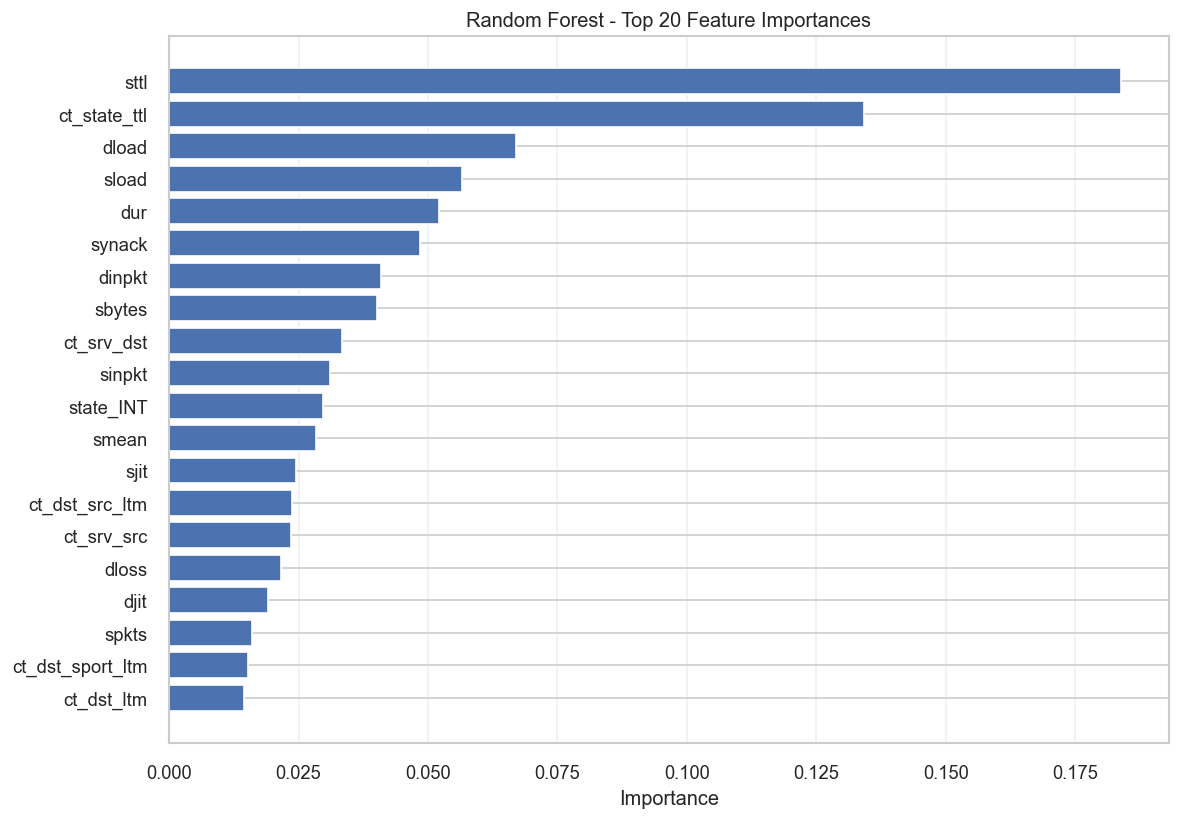

sttl                0.183880
ct_state_ttl        0.134176
dload               0.067047
sload               0.056474
dur                 0.052044
synack              0.048466
dinpkt              0.040937
sbytes              0.040187
ct_srv_dst          0.033323
sinpkt              0.031006
state_INT           0.029734
smean               0.028424
sjit                0.024530
ct_dst_src_ltm      0.023781
ct_srv_src          0.023483
dloss               0.021590
djit                0.019085
spkts               0.016093
ct_dst_sport_ltm    0.015206
ct_dst_ltm          0.014533


In [65]:
if hasattr(X_train, "columns"):
    feat_names = list(X_train.columns)
else:
    feat_names = [f"f{i}" for i in range(X_train.shape[1])]

imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
top20 = imp.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top20.index[::-1], top20.values[::-1])
plt.title("Random Forest - Top 20 Feature Importances")
plt.xlabel("Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(top20.to_string())


## 9. Lưu best model (Random Forest)

In [84]:
import joblib
from pathlib import Path

save_dir = Path(r"unsw_streamlit_best_model_app\models")  # đúng folder bạn dùng
save_dir.mkdir(parents=True, exist_ok=True)

payload = {
    "model": rf,                               # RandomForestClassifier đã fit
    "thr": float(thr_rf),                      # threshold bạn chọn
    "feature_names": list(X_train.columns),    # QUAN TRỌNG: list feature đã train
    "best_model": "RF",
    "score_type": "proba",
}

joblib.dump(payload, save_dir / "best_model.joblib")
print("Saved:", (save_dir / "best_model.joblib").resolve())


Saved: E:\4_DACNTT\DACNTT1\DACNTT\unsw_streamlit_best_model_app\models\best_model.joblib
